In [1]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

test

# implemeting the transition matrix gamma 

In [2]:
import numpy as np

#column 0 = serial 0
#column 1 = serial 1
#column 2 = parallel

def create_transition_matrix(gamma, beta):
    Gamma = np.array([
            [(1-gamma)  ,0          ,gamma],
            [0          ,(1-gamma)  ,gamma],
            [(beta/2)   ,(beta/2)   ,(1-beta)]
            ], dtype=float)
    return Gamma

In [3]:
test_matrix = create_transition_matrix(small_gamma_val, beta_val)
print(test_matrix)
test_matrix[2]

[[0.9 0.  0.1]
 [0.  0.9 0.1]
 [0.1 0.1 0.8]]


array([0.1, 0.1, 0.8])

# implemeting the conditional probability for $Z_{t,i}$

In [4]:
def p_z1_given_c(alpha, c):
    if c == 0:
        return (1-alpha)
    elif c == 1:
        return alpha 
    elif c == 2:
        return (0.5)
    else:
        raise ValueError("c must be 0, 1 or 2")

# simulation

In [5]:
def simulate_c(T, gamma, beta, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    Gamma = create_transition_matrix(gamma, beta)
    #print(Gamma)

    C = np.empty(T, dtype=int)
    C[0] =  2  #P(C_1=2)=1, just the first state

    states = np.array([0, 1, 2], dtype=int)

    for t in range(1, T):
        C[t] = rng.choice(states, p=Gamma[C[t-1]])

    return C

In [6]:
# sim_c = simulate_c(big_T, small_gamma_val, beta_val)
# sim_c

## simulate Z from C

In [7]:
def simulate_z(C, n, alpha, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    T = len(C)

    Z = np.empty((T, n), dtype=int)

    for t in range(T):
        p = p_z1_given_c(alpha, C[t])
        Z[t] = rng.binomial(n=1, p=p, size=n)

    return Z

In [8]:
# sim_z = simulate_z(sim_c, n, alpha_val)
# sim_z

## simulate X from Z

In [9]:
def simulate_x(Z, lambda_0, lambda_1, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    lam = lambda_0 + (lambda_1 - lambda_0) * Z
    X = rng.poisson(lam=lam)
    return X

In [10]:
#sim_x = simulate_x(sim_z, lambda_0, lambda_1)
#sim_x

# Full simulation of HMM

In [11]:
def simulate_hmm(T, n, alpha, beta, gamma, lambda_0, lambda_1, seed=None):
    rng = np.random.default_rng(seed)

    c = simulate_c(T=T, gamma=gamma, beta=beta, rng=rng)
    z = simulate_z(C=c, n=n, alpha=alpha, rng=rng)
    x = simulate_x(Z=z, lambda_0=lambda_0, lambda_1=lambda_1, rng=rng)

    return c, z, x 

In [12]:
C, Z, X = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)

In [13]:
print(C.shape)
print(Z.shape)
print(X.shape)

(100,)
(100, 10)
(100, 10)


# Plotting

In [14]:
import matplotlib.pyplot as plt

In [15]:
def plot_single(X):
    t_vals = np.arange(1, X.shape[0]+1)

    plt.figure(figsize=(12,4))
    plt.plot(t_vals, X[:, 0], marker="o", markersize=4)
    plt.xlabel("t")
    plt.ylabel(r"$X_{t,1}$")
    plt.grid(alpha=0.6)
    plt.title("spikes count over time for neuron 1")
    plt.show()

In [16]:
# plot as a frequency plot to see the distribution of all X values
def plot_freq(X):
    counts = {}
    for i in X:
        for j in i:
            if j in counts:
                counts[j] += 1
            else:
                counts[j] = 1
    plt.figure(figsize=(12,4))
    plt.bar(counts.keys(), counts.values())
    plt.xlabel("spikes count")
    plt.ylabel("frequency")
    plt.title("frequency of spikes count across all neurons and time points")
    plt.grid(alpha=0.6)
    plt.show()

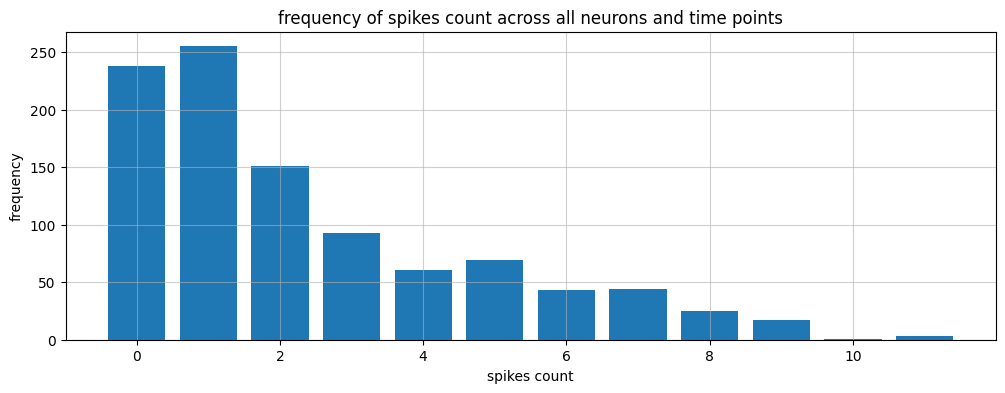

In [17]:
plot_freq(X)

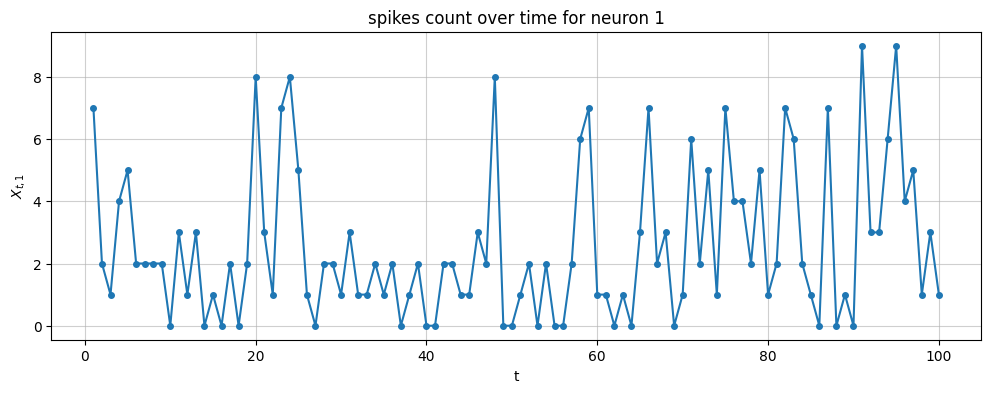

In [18]:
plot_single(X)

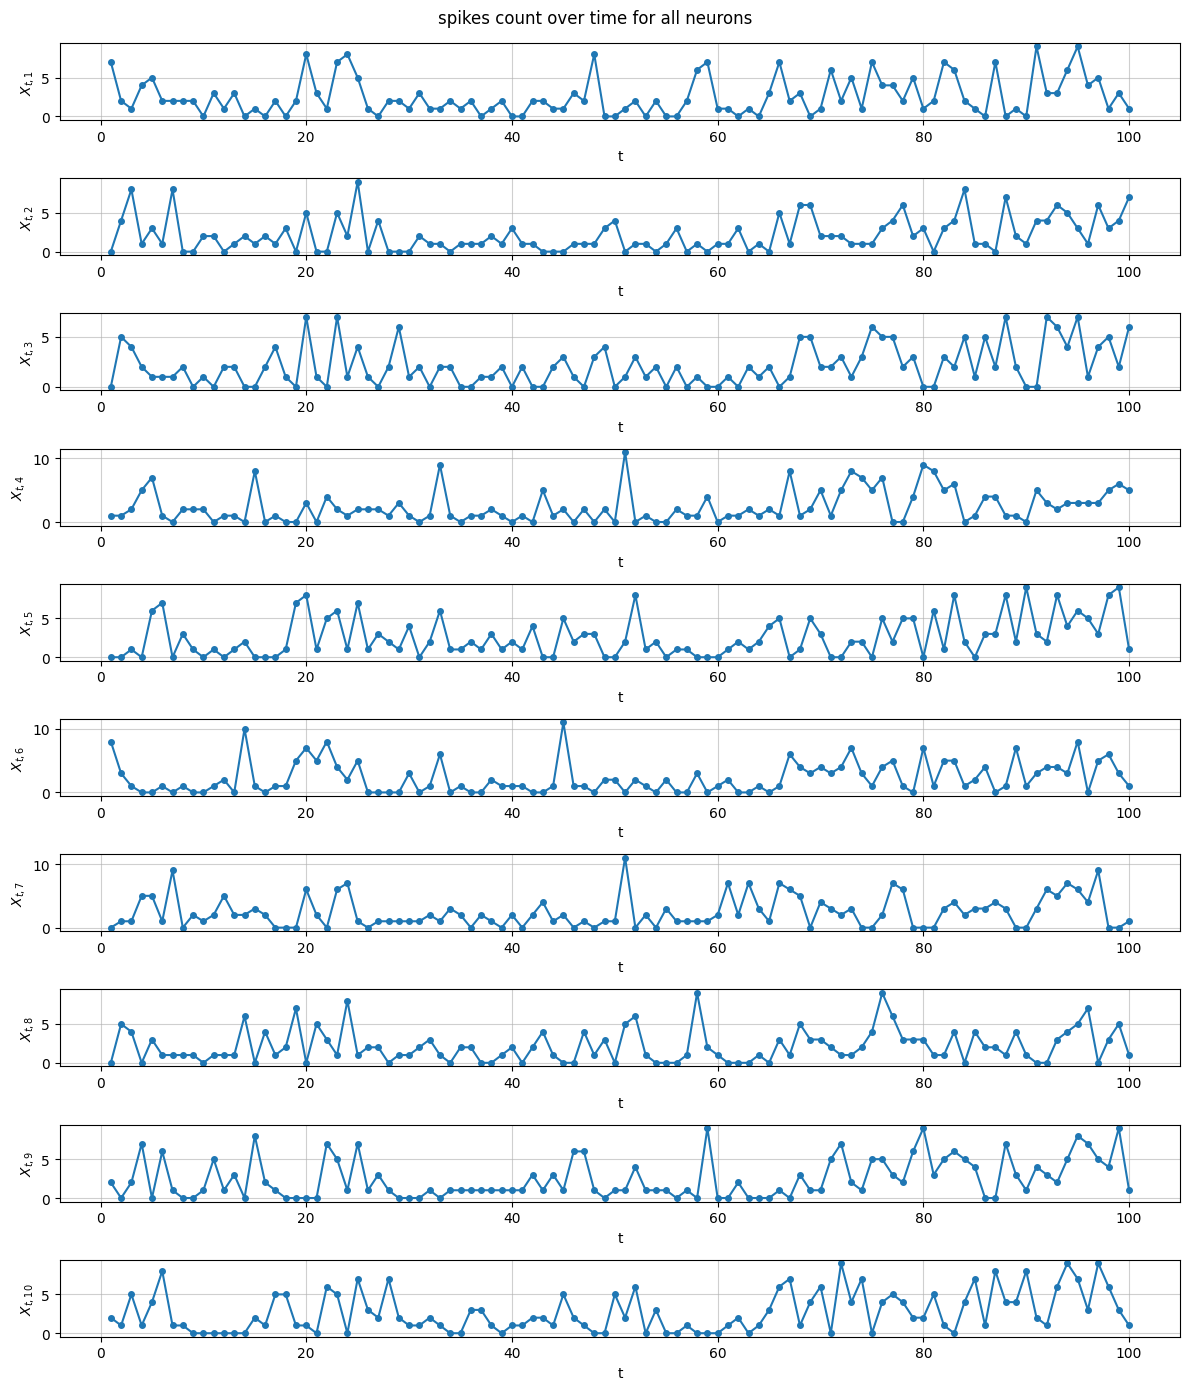

In [19]:
def plot_all(X):
    t_vals = np.arange(1, X.shape[0]+1)
    n = X.shape[1]
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4*n))
    for i in range(n):
        axes[i].plot(t_vals, X[:, i], marker="o", markersize=4)
        axes[i].set_xlabel("t")
        axes[i].set_ylabel(rf"$X_{{t,{i+1}}}$")
        axes[i].grid(alpha=0.6)
    plt.suptitle("spikes count over time for all neurons", y=0.99)
    plt.tight_layout()
    plt.show()

plot_all(X)

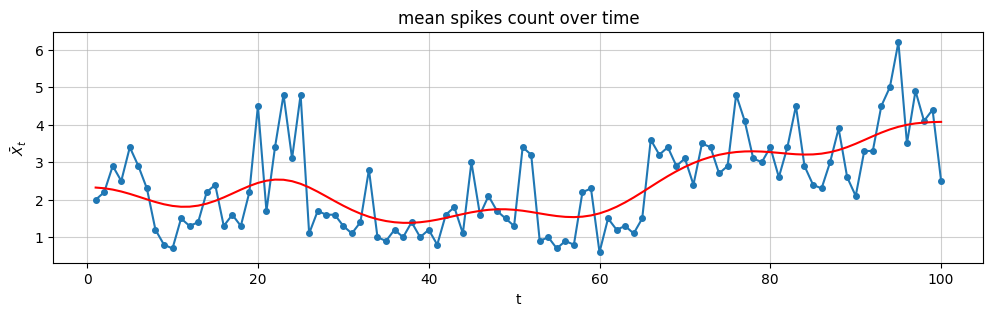

In [20]:
from scipy.ndimage import gaussian_filter1d

def plot_mean(X):
    t_vals = np.arange(1, X.shape[0] + 1)
    mean_X = X.mean(axis=1)
    smooth_mean = gaussian_filter1d(mean_X, sigma=5)

    plt.figure(figsize=(12, 3))
    plt.plot(t_vals, mean_X, marker="o", markersize=4)
    plt.plot(t_vals, smooth_mean, color="r")
    plt.xlabel("t")
    plt.ylabel(r"$\bar{X}_t$")
    plt.grid(alpha=0.6)
    plt.title("mean spikes count over time")
    plt.show()

plot_mean(X)

# multiclass logistic regression of $C_t$ given $X$ for one or more values of t using lots of simulated data

## make datasets

In [21]:
def make_datasets(M, t_index, T, n, alpha, beta, gamma, lambda_0, lambda_1, seed=123):
    rng = np.random.default_rng(seed)

    x_features = np.empty((M, n), dtype=float)      # one row per experiment 
    y_labels = np.empty(M, dtype=int)              # class label C_t in {0, 1, 2}

    for i in range(M):
        # simulate a new HMM sequence
        C, Z, X = simulate_hmm(T=T, n=n, alpha=alpha, beta=beta, gamma=gamma, lambda_0=lambda_0, lambda_1=lambda_1, seed=int(rng.integers(0, 10000000)))
        x_features[i] = X[t_index, :] # features are the spike counts of all neurons at time t_index
        y_labels[i] = C[t_index]     # label is the hidden state at time t_index
    
    return x_features, y_labels

## fit multiclass logistic regression

In [22]:
# first we generate the some dataset
x_features_data = []
y_labels_data = []
t_indexes = [9, 19, 29, 39, 49, 59, 69, 79, 89, 99]
for t_idx in t_indexes:
    # with seed = 123 + t_idx, we get a different dataset for each t_index
    x_features, y_labels = make_datasets(M=1000, t_index=t_idx, T=big_T, n=n, alpha=alpha_val, beta=beta_val, gamma=small_gamma_val, lambda_0=lambda_0, lambda_1=lambda_1, seed= 123 + t_idx)
    x_features_data.append(x_features)
    y_labels_data.append(y_labels)
print(x_features_data[0].shape) # feature shape: (M, n)
print(y_labels_data[0].shape)   # labels shape: (M,)
print("class counts:", np.bincount(y_labels_data[0], minlength=3))

(1000, 10)
(1000,)
class counts: [319 325 356]


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train_data = []
x_test_data = []
y_train_data = []
y_test_data = []

for i in range(len(t_indexes)):
    x_train, x_test, y_train, y_test = train_test_split(x_features_data[i], y_labels_data[i], test_size=0.2, random_state=123)
    x_train_data.append(x_train)
    x_test_data.append(x_test)
    y_train_data.append(y_train)
    y_test_data.append(y_test)

models = []
train_errors = []
test_errors = []

for i in range(len(t_indexes)):
    model = LogisticRegression(max_iter=1000, random_state=123)
    model.fit(x_train_data[i], y_train_data[i])
    
    train_errors.append(1 - model.score(x_train_data[i], y_train_data[i]))
    test_errors.append(1 - model.score(x_test_data[i], y_test_data[i]))
    models.append(model)

for i in range(len(t_indexes)):
    print(f"t={t_indexes[i]+1}: train_error={train_errors[i]:.6f}, test_error={test_errors[i]:.6f}")

t=10: train_error=0.201250, test_error=0.180000
t=20: train_error=0.185000, test_error=0.210000
t=30: train_error=0.176250, test_error=0.230000
t=40: train_error=0.185000, test_error=0.230000
t=50: train_error=0.178750, test_error=0.165000
t=60: train_error=0.177500, test_error=0.215000
t=70: train_error=0.187500, test_error=0.210000
t=80: train_error=0.185000, test_error=0.150000
t=90: train_error=0.168750, test_error=0.195000
t=100: train_error=0.193750, test_error=0.185000


# Part 2

Vi kan skrive

$P(x|C_t=c)=(1-\pi_c)\operatorname{Poisson}(x;\lambda_0)+\pi_c\operatorname{Poisson}(x;\lambda_1)$

In [24]:
import numpy as np
from scipy.stats import poisson

def emission_matrix(X, alpha, lambda0, lambda1):
    T, n = X.shape
    pis = np.array([1-alpha, alpha, 0.5])

    p0 = poisson.pmf(X, mu=lambda0)
    p1 = poisson.pmf(X, mu=lambda1)

    B = np.zeros((T, 3), dtype=float)
    for c in range(3):
        pi = pis[c]
        mix = (1-pi)*p0 + pi*p1    
        B[:, c] = np.prod(mix, axis=1)
    return B

test_emission = emission_matrix(X, alpha_val, lambda_0, lambda_1)

In [25]:
def forward_C(B, Gamma, pi):
    T = B.shape[0]
    scale = np.zeros(T, dtype=float)
    alpha = np.zeros((T, 3), dtype=float)
    alpha[0] = B[0]*pi
    scale[0] = alpha[0].sum()
    alpha[0] = alpha[0]/scale[0]

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ Gamma) * B[t]
        scale[t] = alpha[t].sum()
        alpha[t] = alpha[t]/scale[t]
    
    return alpha, scale

In [26]:
a, s = forward_C(test_emission, test_matrix, np.array([0,0,1]))

In [27]:
def backward_C(B, scale, Gamma):
    T = B.shape[0]
    beta = np.zeros((T,3), dtype=float)
    beta[-1] = 1.0

    for t in range(T-2, -1, -1):
        beta[t] = Gamma @ (B[t+1] * beta[t+1])
        beta[t] = beta[t]/scale[t+1]
    return beta

In [28]:
b = backward_C(test_emission, s, test_matrix)

In [29]:
def compute_smoothed_prob(alpha, beta):
    smoothed = alpha * beta
    smoothed = smoothed / smoothed.sum(axis=1, keepdims=True)  # normalize to get probabilities
    return smoothed


In [30]:
smoothed_probs = compute_smoothed_prob(a, b)

In [31]:
smoothed_probs

array([[0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [3.67390355e-03, 1.56333639e-04, 9.96169763e-01],
       [1.32922422e-03, 8.73432535e-04, 9.97797343e-01],
       [1.17872289e-03, 2.16783577e-04, 9.98604494e-01],
       [3.50006655e-04, 6.77766043e-03, 9.92872333e-01],
       [1.54802631e-01, 3.42037043e-05, 8.45163165e-01],
       [7.53776831e-01, 2.99494959e-08, 2.46223139e-01],
       [9.94155458e-01, 1.49813026e-10, 5.84454219e-03],
       [9.99833879e-01, 1.37828124e-13, 1.66121287e-04],
       [9.99895299e-01, 2.71279030e-14, 1.04701128e-04],
       [9.98055132e-01, 5.77929409e-12, 1.94486756e-03],
       [9.99065884e-01, 2.01421975e-11, 9.34116025e-04],
       [9.98542220e-01, 3.95123138e-10, 1.45777961e-03],
       [9.83230981e-01, 4.50651939e-09, 1.67690149e-02],
       [9.76521174e-01, 2.11629087e-08, 2.34788045e-02],
       [9.95514481e-01, 8.90458823e-09, 4.48551048e-03],
       [9.80011486e-01, 1.49532619e-08, 1.99884995e-02],
       [9.19228724e-01, 4.34447

In [32]:
def posterior_Z(X, qC, alpha, lambda0, lambda1):
    T, n = X.shape
    pis = np.array([1- alpha, alpha, 0.5])

    p0 = poisson.pmf(X, mu=lambda0)
    p1 = poisson.pmf(X, mu=lambda1)

    qZ1_given_c = np.zeros((T, n, 3), dtype=float)

    for c in range(3):
        pi_c = pis[c]
        demoninator = (1 - pi_c)* p0 + pi_c*p1
        qZ1_given_c[:, :, c] = (pi_c*p1) / demoninator

    #marginalize over C_t using qC(t,c)
    qZ1 = np.zeros((T, n), dtype=float)

    for t in range(T):
        for i in range(n):
            # we have the contribution from C_t={0, 1, 2}
            qZ1[t, i ] = (qZ1_given_c[t,i,0] * qC[t,0] + qZ1_given_c[t,i,1] * qC[t,1] + qZ1_given_c[t,i,2] * qC[t,2])
    return qZ1

In [33]:
qz1 = posterior_Z(X, smoothed_probs, alpha_val, lambda_0, lambda_1)

In [34]:
qz1

array([[0.99930163, 0.01798621, 0.01798621, 0.08389522, 0.01798621,
        0.99986025, 0.01798621, 0.01798621, 0.31407765, 0.31407765],
       [0.31317833, 0.91835025, 0.98239487, 0.08368152, 0.0179469 ,
        0.69422657, 0.08368152, 0.98239487, 0.0179469 , 0.08368152],
       [0.08411845, 0.99985887, 0.91924462, 0.31415307, 0.08411845,
        0.08411845, 0.08411845, 0.91924462, 0.31415307, 0.98268412],
       [0.91925233, 0.08388796, 0.31387087, 0.98269198, 0.01799418,
        0.01799418, 0.98269198, 0.01799418, 0.99929522, 0.08388796],
       [0.9828903 , 0.69757235, 0.08636302, 0.9993039 , 0.9965294 ,
        0.01881785, 0.9828903 , 0.69757235, 0.01881785, 0.92001454],
       [0.27296895, 0.07247991, 0.07247991, 0.07247991, 0.99844218,
        0.07247991, 0.07247991, 0.07247991, 0.99233715, 0.9996874 ],
       [0.11382629, 0.99901857, 0.02824965, 0.0059595 , 0.0059595 ,
        0.0059595 , 0.99980352, 0.02824965, 0.02824965, 0.02824965],
       [0.04996633, 0.00212419, 0.0499663